 # libaries that been used

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")
RAW_DIR = PROJECT_ROOT / "data" / "raw"

print("Raw data path:", RAW_DIR.resolve())

Raw data path: /home/mike/Desktop/wind_paper/data/raw


# Net CDF

In [6]:
nc_files = sorted(RAW_DIR.glob("*.nc"))

print(f"Number of NetCDF files: {len(nc_files)}")

for f in nc_files:
    print(f.name)

Number of NetCDF files: 16
2005-01-01_to_2005-12-31.nc
2006-01-01_to_2006-12-31.nc
2007-01-01_to_2007-12-31.nc
2008-01-01_to_2008-12-31.nc
2009-01-01_to_2009-12-31.nc
2010-01-01_to_2010-12-31.nc
2011-01-01_to_2011-12-31.nc
2012-01-01_to_2012-12-31.nc
2013-01-01_to_2013-12-31.nc
2014-01-01_to_2014-12-31.nc
2015-01-01_to_2015-12-31.nc
2016-01-01_to_2016-12-31.nc
2017-01-01_to_2017-12-31.nc
2018-01-01_to_2018-12-31.nc
2019-01-01_to_2019-12-31.nc
2020-01-01_to_2020-12-31.nc


# controll

In [7]:
sample_file = nc_files[0]

ds = xr.open_dataset(sample_file)

print("File:", sample_file.name)
print(ds)

File: 2005-01-01_to_2005-12-31.nc
<xarray.Dataset> Size: 169MB
Dimensions:     (valid_time: 8760, latitude: 37, longitude: 65)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 2005-01-01 ... 2005-12-31T23...
  * latitude    (latitude) float64 296B 31.0 30.75 30.5 ... 22.5 22.25 22.0
  * longitude   (longitude) float64 520B 47.0 47.25 47.5 ... 62.5 62.75 63.0
    expver      (valid_time) <U4 140kB ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 84MB ...
    v10         (valid_time, latitude, longitude) float32 84MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-18T05:14 GRIB to CDM+CF via cfgrib-0.9.1...


# structure

In [8]:
print("DIMENSIONS")
print(ds.dims)

print("\nCOORDINATES")
print(list(ds.coords))

print("\nDATA VARIABLES")
print(list(ds.data_vars))

print("\nATTRIBUTES")
for key, value in ds.attrs.items():
    print(f"{key}: {value}")

DIMENSIONS
FrozenMappingWarningOnValuesAccess({'valid_time': 8760, 'latitude': 37, 'longitude': 65})

COORDINATES
['number', 'valid_time', 'latitude', 'longitude', 'expver']

DATA VARIABLES
['u10', 'v10']

ATTRIBUTES
GRIB_centre: ecmf
GRIB_centreDescription: European Centre for Medium-Range Weather Forecasts
GRIB_subCentre: 0
Conventions: CF-1.7
institution: European Centre for Medium-Range Weather Forecasts
history: 2025-10-18T05:14 GRIB to CDM+CF via cfgrib-0.9.15.0/ecCodes-2.42.0 with {"source": "tmpkn6bffuv/data.grib", "filter_by_keys": {"stream": ["oper"], "stepType": ["instant"]}, "encode_cf": ["parameter", "time", "geography", "vertical"]}


# time and location

In [9]:
print("Latitude:")
print(" min =", float(ds.latitude.min()))
print(" max =", float(ds.latitude.max()))
print(" count =", ds.latitude.size)

print("\nLongitude:")
print(" min =", float(ds.longitude.min()))
print(" max =", float(ds.longitude.max()))
print(" count =", ds.longitude.size)

print("\nTime:")
print(" start =", pd.to_datetime(ds.valid_time.values[0]))
print(" end   =", pd.to_datetime(ds.valid_time.values[-1]))
print(" count =", ds.valid_time.size)

Latitude:
 min = 22.0
 max = 31.0
 count = 37

Longitude:
 min = 47.0
 max = 63.0
 count = 65

Time:
 start = 2005-01-01 00:00:00
 end   = 2005-12-31 23:00:00
 count = 8760


In [10]:
lat_values = np.sort(ds.latitude.values)
lon_values = np.sort(ds.longitude.values)

lat_resolution = np.median(np.abs(np.diff(lat_values)))
lon_resolution = np.median(np.abs(np.diff(lon_values)))

print("Latitude resolution :", lat_resolution)
print("Longitude resolution:", lon_resolution)

Latitude resolution : 0.25
Longitude resolution: 0.25


In [11]:
times = pd.to_datetime(ds.valid_time.values)

time_diff = pd.Series(times).diff().dropna()

print(time_diff.value_counts().head(10))

0 days 01:00:00    8759
Name: count, dtype: int64


# more info

In [12]:
audit_rows = []

for file in nc_files:
    with xr.open_dataset(file) as ds_year:

        times = pd.to_datetime(ds_year["valid_time"].values)
        lat = ds_year["latitude"].values
        lon = ds_year["longitude"].values

        time_diff = pd.Series(times).diff().dropna()

        audit_rows.append({
            "file": file.name,
            "year": times[0].year,

            "n_time": len(times),
            "start_time": times[0],
            "end_time": times[-1],

            "n_lat": len(lat),
            "lat_min": float(np.min(lat)),
            "lat_max": float(np.max(lat)),

            "n_lon": len(lon),
            "lon_min": float(np.min(lon)),
            "lon_max": float(np.max(lon)),

            "time_step_mode": time_diff.mode().iloc[0]
                if len(time_diff) > 0 else None,

            "u10_dims": str(ds_year["u10"].shape),
            "v10_dims": str(ds_year["v10"].shape),

            "u10_nan": int(ds_year["u10"].isnull().sum().values),
            "v10_nan": int(ds_year["v10"].isnull().sum().values),
        })

audit_df = pd.DataFrame(audit_rows)

audit_df

,file,year,n_time,start_time,end_time,n_lat,lat_min,lat_max,n_lon,lon_min,lon_max,time_step_mode,u10_dims,v10_dims,u10_nan,v10_nan
0,2005-01-01_to_2005-12-31.nc,2005,8760,2005-01-01,2005-12-31 23:00:00,37,22.0,31.0,65,47.0,63.0,0 days 01:00:00,"(8760, 37, 65)","(8760, 37, 65)",0,0
1,2006-01-01_to_2006-12-31.nc,2006,8760,2006-01-01,2006-12-31 23:00:00,37,22.0,31.0,65,47.0,63.0,0 days 01:00:00,"(8760, 37, 65)","(8760, 37, 65)",0,0
2,2007-01-01_to_2007-12-31.nc,2007,8760,2007-01-01,2007-12-31 23:00:00,37,22.0,31.0,65,47.0,63.0,0 days 01:00:00,"(8760, 37, 65)","(8760, 37, 65)",0,0
3,2008-01-01_to_2008-12-31.nc,2008,8784,2008-01-01,2008-12-31 23:00:00,37,22.0,31.0,65,47.0,63.0,0 days 01:00:00,"(8784, 37, 65)","(8784, 37, 65)",0,0
4,2009-01-01_to_2009-12-31.nc,2009,8760,2009-01-01,2009-12-31 23:00:00,37,22.0,31.0,65,47.0,63.0,0 days 01:00:00,"(8760, 37, 65)","(8760, 37, 65)",0,0
5,2010-01-01_to_2010-12-31.nc,2010,8760,2010-01-01,2010-12-31 23:00:00,37,22.0,31.0,65,47.0,63.0,0 days 01:00:00,"(8760, 37, 65)","(8760, 37, 65)",0,0
6,2011-01-01_to_2011-12-31.nc,2011,8760,2011-01-01,2011-12-31 23:00:00,37,22.0,31.0,65,47.0,63.0,0 days 01:00:00,"(8760, 37, 65)","(8760, 37, 65)",0,0
7,2012-01-01_to_2012-12-31.nc,2012,8784,2012-01-01,2012-12-31 23:00:00,37,22.0,31.0,65,47.0,63.0,0 days 01:00:00,"(8784, 37, 65)","(8784, 37, 65)",0,0
8,2013-01-01_to_2013-12-31.nc,2013,8760,2013-01-01,2013-12-31 23:00:00,37,22.0,31.0,65,47.0,63.0,0 days 01:00:00,"(8760, 37, 65)","(8760, 37, 65)",0,0
9,2014-01-01_to_2014-12-31.nc,2014,8760,2014-01-01,2014-12-31 23:00:00,37,22.0,31.0,65,47.0,63.0,0 days 01:00:00,"(8760, 37, 65)","(8760, 37, 65)",0,0


In [13]:
print(
    audit_df[
        [
            "year",
            "n_time",
            "start_time",
            "end_time",
            "n_lat",
            "n_lon",
            "time_step_mode",
            "u10_nan",
            "v10_nan"
        ]
    ].to_string(index=False)
)

 year  n_time start_time            end_time  n_lat  n_lon  time_step_mode  u10_nan  v10_nan
 2005    8760 2005-01-01 2005-12-31 23:00:00     37     65 0 days 01:00:00        0        0
 2006    8760 2006-01-01 2006-12-31 23:00:00     37     65 0 days 01:00:00        0        0
 2007    8760 2007-01-01 2007-12-31 23:00:00     37     65 0 days 01:00:00        0        0
 2008    8784 2008-01-01 2008-12-31 23:00:00     37     65 0 days 01:00:00        0        0
 2009    8760 2009-01-01 2009-12-31 23:00:00     37     65 0 days 01:00:00        0        0
 2010    8760 2010-01-01 2010-12-31 23:00:00     37     65 0 days 01:00:00        0        0
 2011    8760 2011-01-01 2011-12-31 23:00:00     37     65 0 days 01:00:00        0        0
 2012    8784 2012-01-01 2012-12-31 23:00:00     37     65 0 days 01:00:00        0        0
 2013    8760 2013-01-01 2013-12-31 23:00:00     37     65 0 days 01:00:00        0        0
 2014    8760 2014-01-01 2014-12-31 23:00:00     37     65 0 days 01:0

In [14]:
expected_hours = {
    year: 8784 if pd.Timestamp(year=year, month=12, day=31).is_leap_year else 8760
    for year in audit_df["year"]
}

audit_df["expected_hours"] = audit_df["year"].map(expected_hours)
audit_df["time_count_ok"] = audit_df["n_time"] == audit_df["expected_hours"]

audit_df[
    ["year", "n_time", "expected_hours", "time_count_ok"]
]

,year,n_time,expected_hours,time_count_ok
0,2005,8760,8760,True
1,2006,8760,8760,True
2,2007,8760,8760,True
3,2008,8784,8784,True
4,2009,8760,8760,True
5,2010,8760,8760,True
6,2011,8760,8760,True
7,2012,8784,8784,True
8,2013,8760,8760,True
9,2014,8760,8760,True


In [15]:
print("Unique latitude counts:", audit_df["n_lat"].unique())
print("Unique longitude counts:", audit_df["n_lon"].unique())

print("Latitude min values:", audit_df["lat_min"].unique())
print("Latitude max values:", audit_df["lat_max"].unique())

print("Longitude min values:", audit_df["lon_min"].unique())
print("Longitude max values:", audit_df["lon_max"].unique())

Unique latitude counts: [37]
Unique longitude counts: [65]
Latitude min values: [22.]
Latitude max values: [31.]
Longitude min values: [47.]
Longitude max values: [63.]


In [16]:
print("Total u10 missing values:", audit_df["u10_nan"].sum())
print("Total v10 missing values:", audit_df["v10_nan"].sum())

Total u10 missing values: 0
Total v10 missing values: 0


In [17]:
problems = audit_df[
    (~audit_df["time_count_ok"]) |
    (audit_df["n_lat"] != 37) |
    (audit_df["n_lon"] != 65) |
    (audit_df["time_step_mode"] != pd.Timedelta(hours=1)) |
    (audit_df["u10_nan"] > 0) |
    (audit_df["v10_nan"] > 0)
]

if problems.empty:
    print("PASS: All yearly NetCDF files are structurally consistent.")
else:
    print("WARNING: Problems found:")
    display(problems)

PASS: All yearly NetCDF files are structurally consistent.


# saving the results

In [18]:
AUDIT_OUTPUT = PROJECT_ROOT / "outputs" / "tables"
AUDIT_OUTPUT.mkdir(parents=True, exist_ok=True)

audit_df.to_csv(
    AUDIT_OUTPUT / "yearly_data_audit.csv",
    index=False
)

print("Saved:", AUDIT_OUTPUT / "yearly_data_audit.csv")

Saved: ../outputs/tables/yearly_data_audit.csv


In [19]:
stats_rows = []

for file in nc_files:
    with xr.open_dataset(file) as ds_year:

        u = ds_year["u10"]
        v = ds_year["v10"]

        stats_rows.append({
            "year": int(ds_year.valid_time.dt.year.values[0]),

            "u10_min": float(u.min().values),
            "u10_max": float(u.max().values),
            "u10_mean": float(u.mean().values),
            "u10_std": float(u.std().values),

            "v10_min": float(v.min().values),
            "v10_max": float(v.max().values),
            "v10_mean": float(v.mean().values),
            "v10_std": float(v.std().values),
        })

stats_df = pd.DataFrame(stats_rows)

stats_df

,year,u10_min,u10_max,u10_mean,u10_std,v10_min,v10_max,v10_mean,v10_std
0,2005,-13.385971,14.512711,0.528160,2.661067,-16.797729,16.366257,-0.455220,3.139213
1,2006,-13.537582,13.437759,0.565323,2.680956,-15.081329,15.620499,-0.401392,3.142428
2,2007,-27.240021,24.780792,0.548925,2.661702,-25.550079,29.988739,-0.626374,3.148382
3,2008,-11.154800,16.386353,0.731331,2.673843,-16.034927,16.324478,-0.594978,3.173682
4,2009,-14.403091,15.377548,0.646183,2.680359,-15.988953,17.506760,-0.385478,3.129896
5,2010,-20.771042,17.956360,0.574207,2.597347,-18.213348,23.445038,-0.473184,3.049382
6,2011,-13.009506,14.652878,0.656566,2.693707,-16.111786,15.453644,-0.541311,3.224503
7,2012,-13.674271,15.402145,0.584078,2.692877,-19.244171,17.237106,-0.498394,3.235493
8,2013,-13.885010,14.518524,0.585645,2.696220,-16.383499,16.326538,-0.439882,3.184815
9,2014,-13.367172,13.530014,0.472036,2.655936,-15.878372,16.606384,-0.541266,3.086992


In [20]:
wind_stats_rows = []

for file in nc_files:
    with xr.open_dataset(file) as ds_year:

        ws = np.sqrt(
            ds_year["u10"]**2 +
            ds_year["v10"]**2
        )

        wind_stats_rows.append({
            "year": int(ds_year.valid_time.dt.year.values[0]),

            "ws_min": float(ws.min().values),
            "ws_max": float(ws.max().values),
            "ws_mean": float(ws.mean().values),
            "ws_std": float(ws.std().values),
        })

wind_stats_df = pd.DataFrame(wind_stats_rows)

print(wind_stats_df.to_string(index=False))

 year   ws_min    ws_max  ws_mean   ws_std
 2005 0.001140 17.157980 3.560308 2.178599
 2006 0.000674 16.112476 3.572934 2.185682
 2007 0.000789 29.990341 3.582992 2.202909
 2008 0.000487 16.907772 3.631148 2.219300
 2009 0.000270 17.762493 3.579194 2.176245
 2010 0.000377 23.684183 3.480853 2.117129
 2011 0.000896 16.649315 3.654300 2.241354
 2012 0.000497 20.804869 3.628355 2.268167
 2013 0.001709 17.023357 3.608345 2.220130
 2014 0.000495 16.813099 3.542929 2.132359
 2015 0.001388 20.493158 3.656126 2.253201
 2016 0.000856 16.870167 3.547139 2.185033
 2017 0.000642 17.883814 3.556156 2.226235
 2018 0.000715 17.135805 3.536695 2.134930
 2019 0.000918 17.964600 3.582785 2.205169
 2020 0.000415 17.687897 3.574630 2.159608


In [21]:
print("Global u10:")
print("min:", stats_df["u10_min"].min())
print("max:", stats_df["u10_max"].max())

print("\nGlobal v10:")
print("min:", stats_df["v10_min"].min())
print("max:", stats_df["v10_max"].max())

print("\nGlobal wind speed:")
print("min:", wind_stats_df["ws_min"].min())
print("max:", wind_stats_df["ws_max"].max())

Global u10:
min: -27.240020751953125
max: 24.780792236328125

Global v10:
min: -25.550079345703125
max: 29.988739013671875

Global wind speed:
min: 0.00026995554799214005
max: 29.990341186523438


In [22]:
boundaries = []

for i in range(len(nc_files) - 1):

    with xr.open_dataset(nc_files[i]) as ds_a:
        end_time = pd.Timestamp(ds_a.valid_time.values[-1])

    with xr.open_dataset(nc_files[i + 1]) as ds_b:
        start_time = pd.Timestamp(ds_b.valid_time.values[0])

    gap = start_time - end_time

    boundaries.append({
        "from_file": nc_files[i].name,
        "to_file": nc_files[i + 1].name,
        "end_time": end_time,
        "next_start": start_time,
        "gap": gap,
        "continuous": gap == pd.Timedelta(hours=1)
    })

boundary_df = pd.DataFrame(boundaries)

print(
    boundary_df[
        ["from_file", "to_file", "gap", "continuous"]
    ].to_string(index=False)
)

                  from_file                     to_file             gap  continuous
2005-01-01_to_2005-12-31.nc 2006-01-01_to_2006-12-31.nc 0 days 01:00:00        True
2006-01-01_to_2006-12-31.nc 2007-01-01_to_2007-12-31.nc 0 days 01:00:00        True
2007-01-01_to_2007-12-31.nc 2008-01-01_to_2008-12-31.nc 0 days 01:00:00        True
2008-01-01_to_2008-12-31.nc 2009-01-01_to_2009-12-31.nc 0 days 01:00:00        True
2009-01-01_to_2009-12-31.nc 2010-01-01_to_2010-12-31.nc 0 days 01:00:00        True
2010-01-01_to_2010-12-31.nc 2011-01-01_to_2011-12-31.nc 0 days 01:00:00        True
2011-01-01_to_2011-12-31.nc 2012-01-01_to_2012-12-31.nc 0 days 01:00:00        True
2012-01-01_to_2012-12-31.nc 2013-01-01_to_2013-12-31.nc 0 days 01:00:00        True
2013-01-01_to_2013-12-31.nc 2014-01-01_to_2014-12-31.nc 0 days 01:00:00        True
2014-01-01_to_2014-12-31.nc 2015-01-01_to_2015-12-31.nc 0 days 01:00:00        True
2015-01-01_to_2015-12-31.nc 2016-01-01_to_2016-12-31.nc 0 days 01:00:00     

In [23]:
file_2007 = RAW_DIR / "2007-01-01_to_2007-12-31.nc"

with xr.open_dataset(file_2007) as ds_2007:
    ws_2007 = np.sqrt(ds_2007["u10"]**2 + ds_2007["v10"]**2)

    flat_index = int(ws_2007.argmax().values)
    idx = np.unravel_index(flat_index, ws_2007.shape)

    t_idx, lat_idx, lon_idx = idx

    print("Maximum wind speed:", float(ws_2007.values[idx]), "m/s")
    print("u10:", float(ds_2007["u10"].values[idx]))
    print("v10:", float(ds_2007["v10"].values[idx]))
    print("Time:", pd.Timestamp(ds_2007.valid_time.values[t_idx]))
    print("Latitude:", float(ds_2007.latitude.values[lat_idx]))
    print("Longitude:", float(ds_2007.longitude.values[lon_idx]))

Maximum wind speed: 29.990341186523438 m/s
u10: 0.309967041015625
v10: 29.988739013671875
Time: 2007-06-05 17:00:00
Latitude: 22.0
Longitude: 61.0


In [24]:
import regionmask
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


In [25]:
with xr.open_dataset(nc_files[0]) as ds_sample:
    lat = ds_sample["latitude"]
    lon = ds_sample["longitude"]

land_regions = regionmask.defined_regions.natural_earth_v5_0_0.land_10

land_mask = land_regions.mask(lon, lat)

land_mask

<xarray.DataArray 'mask' (latitude: 37, longitude: 65)> Size: 19kB
array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ..., nan, nan, nan],
       [ 0.,  0.,  0., ..., nan, nan, nan],
       [ 0.,  0.,  0., ..., nan, nan, nan]], shape=(37, 65))
Coordinates:
    number     int64 8B 0
  * latitude   (latitude) float64 296B 31.0 30.75 30.5 30.25 ... 22.5 22.25 22.0
  * longitude  (longitude) float64 520B 47.0 47.25 47.5 ... 62.5 62.75 63.0
Attributes:
    standard_name:  region
    flag_values:    [0]
    flag_meanings:  lnd

In [27]:
sea_mask = land_mask.isnull()

print("Total grid cells:", sea_mask.size)
print("Sea cells:", int(sea_mask.sum().values))
print("Land cells:", int((~sea_mask).sum().values))

Total grid cells: 2405
Sea cells: 650
Land cells: 1755


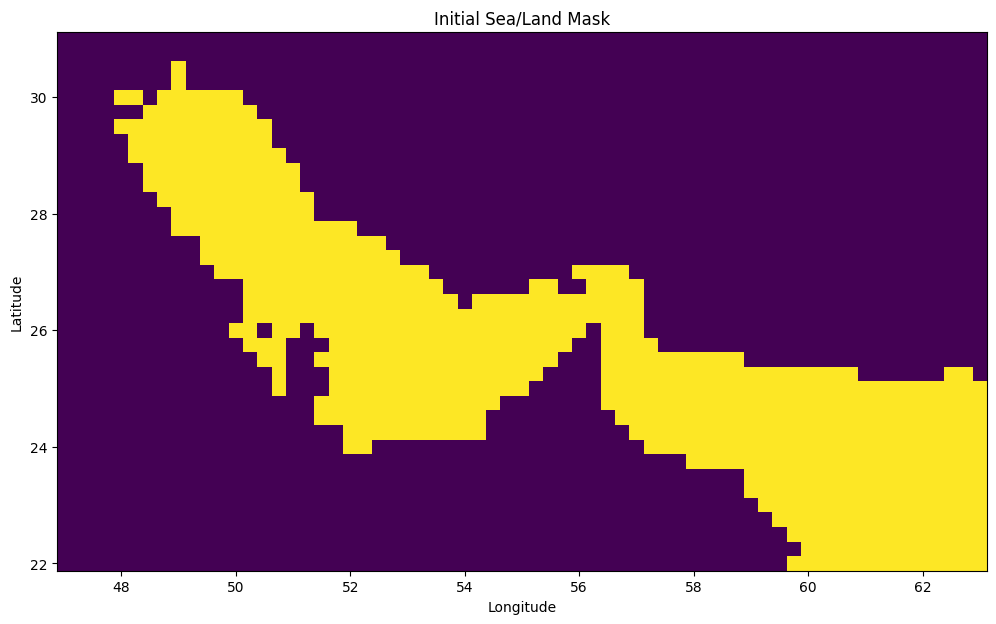

In [28]:
plt.figure(figsize=(12, 7))

plt.pcolormesh(
    lon.values,
    lat.values,
    sea_mask.values,
    shading="auto"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Initial Sea/Land Mask")
plt.show()

In [29]:
MASK_DIR = PROJECT_ROOT / "data" / "processed"
MASK_DIR.mkdir(parents=True, exist_ok=True)

sea_mask.name = "sea_mask"

sea_mask.to_netcdf(
    MASK_DIR / "initial_sea_mask.nc"
)

print("Saved:", MASK_DIR / "initial_sea_mask.nc")

Saved: ../data/processed/initial_sea_mask.nc


In [30]:
# Apply sea mask to one sample year for verification

with xr.open_dataset(nc_files[0]) as ds_sample:

    ds_sea = ds_sample.where(sea_mask)

    print(ds_sea)

<xarray.Dataset> Size: 169MB
Dimensions:     (valid_time: 8760, latitude: 37, longitude: 65)
Coordinates:
    number      int64 8B 0
  * valid_time  (valid_time) datetime64[ns] 70kB 2005-01-01 ... 2005-12-31T23...
  * latitude    (latitude) float64 296B 31.0 30.75 30.5 ... 22.5 22.25 22.0
  * longitude   (longitude) float64 520B 47.0 47.25 47.5 ... 62.5 62.75 63.0
    expver      (valid_time) <U4 140kB ...
Data variables:
    u10         (valid_time, latitude, longitude) float32 84MB nan ... 0.1585
    v10         (valid_time, latitude, longitude) float32 84MB nan ... -6.675
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-18T05:14 GRIB to CDM+CF via cfgrib-0.9.1...


In [31]:
with xr.open_dataset(nc_files[0]) as ds_sample:

    ds_sea_points = (
        ds_sample[["u10", "v10"]]
        .stack(grid=("latitude", "longitude"))
    )

    mask_1d = sea_mask.stack(grid=("latitude", "longitude"))

    ds_sea_points = ds_sea_points.sel(
        grid=mask_1d.where(mask_1d, drop=True).grid
    )

    print(ds_sea_points)
    print("Number of marine grid cells:", ds_sea_points.sizes["grid"])

<xarray.Dataset> Size: 46MB
Dimensions:     (valid_time: 8760, grid: 650)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 70kB 2005-01-01 ... 2005-12-31T23...
    expver      (valid_time) <U4 140kB ...
  * grid        (grid) object 5kB MultiIndex
  * latitude    (grid) float64 5kB 30.5 30.25 30.0 30.0 ... 22.0 22.0 22.0 22.0
  * longitude   (grid) float64 5kB 49.0 49.0 48.0 48.25 ... 62.5 62.75 63.0
Data variables:
    u10         (valid_time, grid) float32 23MB 0.9249 1.32 ... -0.6628 0.1585
    v10         (valid_time, grid) float32 23MB -0.987 -1.942 ... -7.092 -6.675
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-18T05:14 GRIB to CDM+CF via cfgrib-0.9.1...
Number of marine grid cells: 6

In [32]:
print(ds_sea_points["grid"].values[:20])

[(30.5, 49.0) (30.25, 49.0) (30.0, 48.0) (30.0, 48.25) (30.0, 48.75)
 (30.0, 49.0) (30.0, 49.25) (30.0, 49.5) (30.0, 49.75) (30.0, 50.0)
 (29.75, 48.5) (29.75, 48.75) (29.75, 49.0) (29.75, 49.25) (29.75, 49.5)
 (29.75, 49.75) (29.75, 50.0) (29.75, 50.25) (29.5, 48.0) (29.5, 48.25)]


In [33]:
n_time = ds_sea_points.sizes["valid_time"]
n_grid = ds_sea_points.sizes["grid"]

print("Hours:", n_time)
print("Marine cells:", n_grid)
print("Marine grid-time samples:", n_time * n_grid)

Hours: 8760
Marine cells: 650
Marine grid-time samples: 5694000


In [34]:
MASK_PATH = PROJECT_ROOT / "data" / "processed" / "marine_mask.nc"

sea_mask.name = "marine_mask"
sea_mask.to_netcdf(MASK_PATH)

print("Saved:", MASK_PATH)

Saved: ../data/processed/marine_mask.nc


In [35]:
marine_grid = pd.DataFrame({
    "latitude": ds_sea_points["latitude"].values,
    "longitude": ds_sea_points["longitude"].values,
})

marine_grid.insert(
    0,
    "grid_id",
    np.arange(len(marine_grid))
)

marine_grid.to_csv(
    PROJECT_ROOT / "data" / "processed" / "marine_grid.csv",
    index=False
)

marine_grid.head()

,grid_id,latitude,longitude
0,0,30.50,49.00
1,1,30.25,49.00
2,2,30.00,48.00
3,3,30.00,48.25
4,4,30.00,48.75


In [37]:
from pathlib import Path
import geopandas as gpd

IHO_DIR = PROJECT_ROOT / "data" / "external" / "iho" / "World_Seas_IHO_v3"

shp_files = list(IHO_DIR.glob("*.shp"))

print("Shapefiles found:", len(shp_files))

for f in shp_files:
    print(f.name)

Shapefiles found: 1
World_Seas_IHO_v3.shp


In [38]:
iho_path = shp_files[0]

iho = gpd.read_file(iho_path)

print("Shape:", iho.shape)
print("CRS:", iho.crs)
print("Columns:")
print(iho.columns.tolist())

iho.head()

Shape: (101, 11)
CRS: EPSG:4326
Columns:
['NAME', 'ID', 'Longitude', 'Latitude', 'min_X', 'min_Y', 'max_X', 'max_Y', 'area', 'MRGID', 'geometry']


,NAME,ID,Longitude,Latitude,min_X,min_Y,max_X,max_Y,area,MRGID,geometry
0,Rio de La Plata,33,-56.842478,-35.113338,-59.765656,-36.358856,-54.943024,-31.523437,31797,4325,"POLYGON ((-54.94302 -34.94791, -54.97875 -34.9..."
1,Bass Strait,62A,146.424291,-39.450520,143.532508,-41.440274,149.909468,-37.460793,112699,4366,"POLYGON ((149.90464 -37.54325, 149.905 -37.548..."
2,Great Australian Bight,62,132.716558,-36.725916,117.614198,-43.566016,146.231156,-31.463669,1326209,4276,"POLYGON ((143.53251 -38.85535, 143.54856 -38.8..."
3,Tasman Sea,63,160.710798,-39.701056,146.872615,-50.866916,175.286985,-30.000000,3344624,4365,"POLYGON ((159.03333 -30, 159.03983 -30.0435, 1..."
4,Mozambique Channel,45A,40.877244,-19.304095,32.430623,-26.842402,49.241982,-10.498872,1394283,4261,"POLYGON ((43.38218 -11.37021, 43.42691 -11.374..."


In [39]:
text_cols = [
    col for col in iho.columns
    if iho[col].dtype == "object"
]

for col in text_cols:
    mask = (
        iho[col]
        .astype(str)
        .str.contains(
            "Persian Gulf|Gulf of Oman|Oman",
            case=False,
            na=False,
            regex=True
        )
    )

    if mask.any():
        print("\nMATCHING COLUMN:", col)
        print(iho.loc[mask, [col]])


MATCHING COLUMN: NAME
            NAME
35  Gulf of Oman
38  Persian Gulf


In [41]:
study_basins = iho[
    iho["NAME"].isin(["Persian Gulf", "Gulf of Oman"])
].copy()

study_basins[["NAME", "ID", "MRGID", "area"]]

,NAME,ID,MRGID,area
35,Gulf of Oman,40,4267,111892
38,Persian Gulf,41,4266,244657


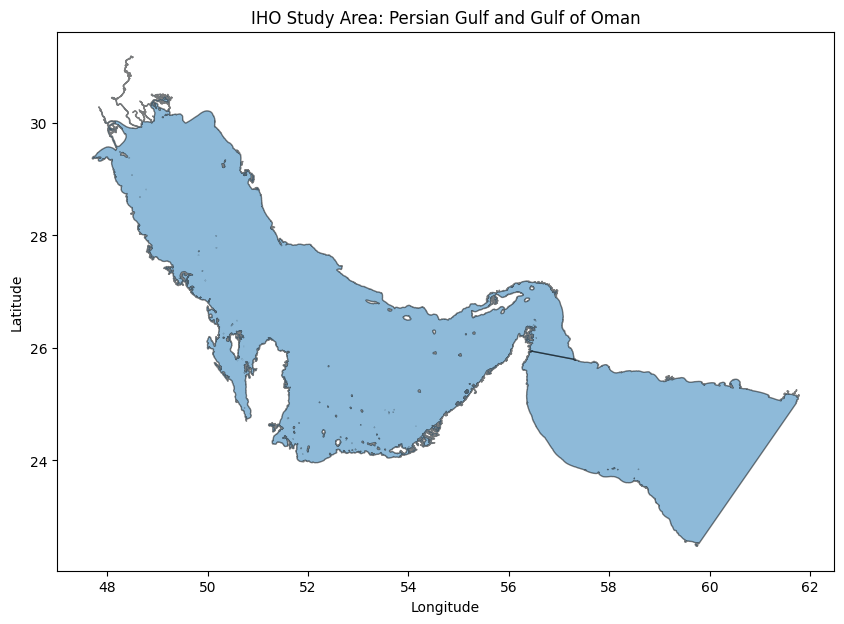

In [42]:
fig, ax = plt.subplots(figsize=(12, 7))

study_basins.plot(
    ax=ax,
    alpha=0.5,
    edgecolor="black"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("IHO Study Area: Persian Gulf and Gulf of Oman")

plt.show()

In [43]:
marine_gdf = gpd.GeoDataFrame(
    marine_grid.copy(),
    geometry=gpd.points_from_xy(
        marine_grid["longitude"],
        marine_grid["latitude"]
    ),
    crs="EPSG:4326"
)

marine_gdf.head()

,grid_id,latitude,longitude,geometry
0,0,30.50,49.00,POINT (49 30.5)
1,1,30.25,49.00,POINT (49 30.25)
2,2,30.00,48.00,POINT (48 30)
3,3,30.00,48.25,POINT (48.25 30)
4,4,30.00,48.75,POINT (48.75 30)


In [44]:
marine_grid = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "marine_grid.csv"
)

marine_gdf = gpd.GeoDataFrame(
    marine_grid,
    geometry=gpd.points_from_xy(
        marine_grid["longitude"],
        marine_grid["latitude"]
    ),
    crs="EPSG:4326"
)

In [45]:
study_grid = gpd.sjoin(
    marine_gdf,
    study_basins[["NAME", "geometry"]],
    how="inner",
    predicate="intersects"
)

study_grid = study_grid.rename(
    columns={"NAME": "basin"}
)

study_grid.head()

,grid_id,latitude,longitude,geometry,index_right,basin
1,1,30.25,49.00,POINT (49 30.25),38,Persian Gulf
2,2,30.00,48.00,POINT (48 30),38,Persian Gulf
3,3,30.00,48.25,POINT (48.25 30),38,Persian Gulf
4,4,30.00,48.75,POINT (48.75 30),38,Persian Gulf
5,5,30.00,49.00,POINT (49 30),38,Persian Gulf


In [46]:
print("Original marine cells:", len(marine_gdf))
print("Study-area cells:", len(study_grid))

print("\nCells by basin:")
print(study_grid["basin"].value_counts())

Original marine cells: 650
Study-area cells: 512

Cells by basin:
basin
Persian Gulf    357
Gulf of Oman    155
Name: count, dtype: int64


In [47]:
duplicates = study_grid[
    study_grid.duplicated(
        subset="grid_id",
        keep=False
    )
]

print("Duplicate boundary cells:", len(duplicates))

if len(duplicates) > 0:
    print(
        duplicates[
            ["grid_id", "latitude", "longitude", "basin"]
        ]
    )

Duplicate boundary cells: 0


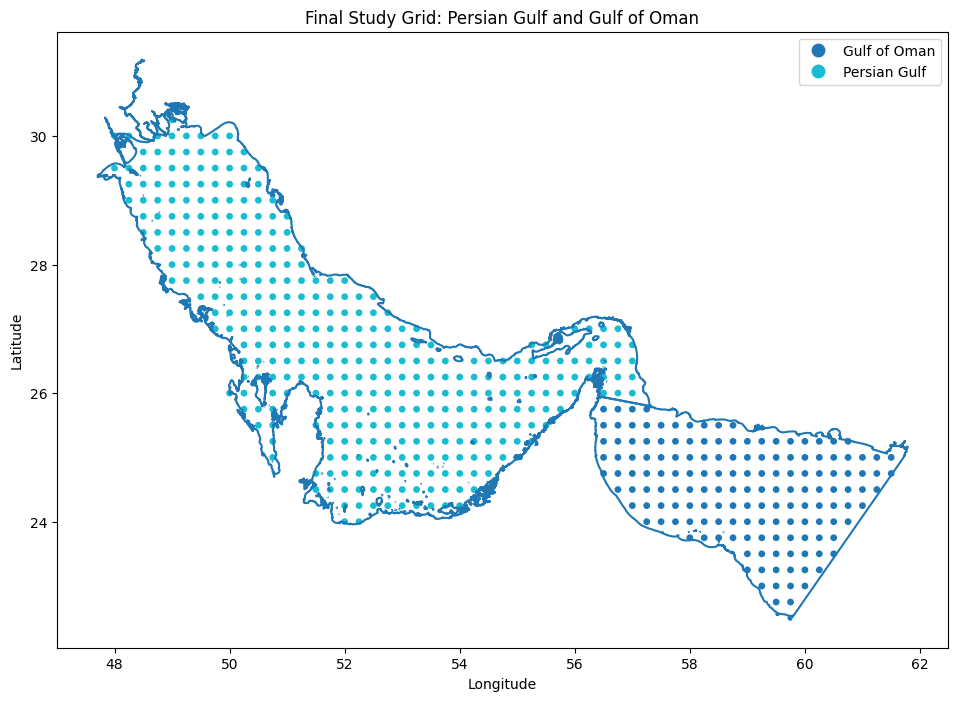

In [48]:
fig, ax = plt.subplots(figsize=(13, 8))

study_basins.boundary.plot(
    ax=ax,
    linewidth=1.5
)

study_grid.plot(
    ax=ax,
    column="basin",
    markersize=15,
    legend=True
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    "Final Study Grid: Persian Gulf and Gulf of Oman"
)

plt.show()

In [49]:
study_grid_output = (
    study_grid[
        ["grid_id", "latitude", "longitude", "basin"]
    ]
    .sort_values(["basin", "latitude", "longitude"])
    .reset_index(drop=True)
)

study_grid_output.to_csv(
    PROJECT_ROOT / "data" / "processed" / "study_grid.csv",
    index=False
)

study_grid_output.head()

,grid_id,latitude,longitude,basin
0,594,22.75,59.50,Gulf of Oman
1,595,22.75,59.75,Gulf of Oman
2,578,23.00,59.25,Gulf of Oman
3,579,23.00,59.50,Gulf of Oman
4,580,23.00,59.75,Gulf of Oman


In [50]:
study_grid_output.insert(
    0,
    "study_id",
    np.arange(len(study_grid_output))
)

study_grid_output.to_csv(
    PROJECT_ROOT / "data" / "processed" / "study_grid.csv",
    index=False
)